# Climate & Pollution Analysis - Step 2 - Component Reduction
Here we look at some of the multivariate distributions for the climate and the pollution data. We will use this to decide whether eigenvectors separate the climate and pollution regimes effectively. The first step is to read in the Scottish climate and pollution data. These datasets are taken from DEFRA and CEDA and downloaded separately. In this case, we are considering Scotland to be any location in the datasets with a latitude of greater than 55 degrees North (approximately Newcastle). 
1. Climate Data - [CEDA](https://catalogue.ceda.ac.uk/uuid/4dc8450d889a491ebb20e724debe2dfb/) has monthly climate observations for a range of indicators 
2. Pollution Data - DEFRA has a variety of different datasets

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import numpy as np
import numpy as np


# Import the datasets
pollutants = ['Benzene', 'NO2', 'NOx', 'Ozone', 'PM10', 'PM2.5',
       'SO2']
climate_measures = ['groundfrost', 'hurs', 'rainfall',
       'sfcWind', 'snowLying', 'sun', 'tas', 'tasmax', 'tasmin']
df_poll_pivot = pd.read_csv('scotland_annual_pollution_pivot.csv')
df_clim_pivot = pd.read_csv('scotland_monthly_climate_pivot.csv')

## Pollutants - Correlation
The first chart shows the correlation matrix between the different types of pollutants. The chart shows a high level of correlation between different types of pollutants. The only major independent pollutant is Ozone, but there are significant issues with Ozone which we will return to.

### Pollutants - Cluster Analysis
Using a dendrogram to perform a simple cluster analysis allows us to pick out three components that can be used as a proxy for all of the pollution:
1. PM2.5
2. Ozone
3. NO$_2$

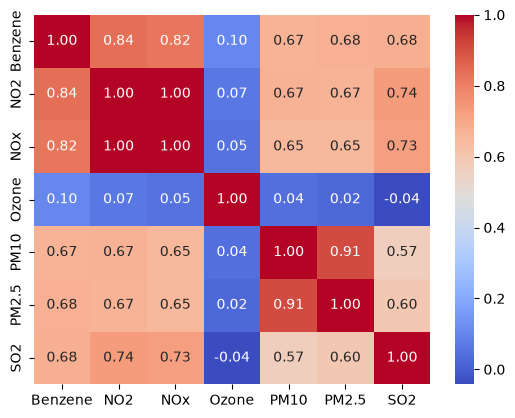

In [34]:
_ = sns.heatmap(df_poll_pivot[pollutants].corr(), annot=True, cmap='coolwarm', fmt='.2f')

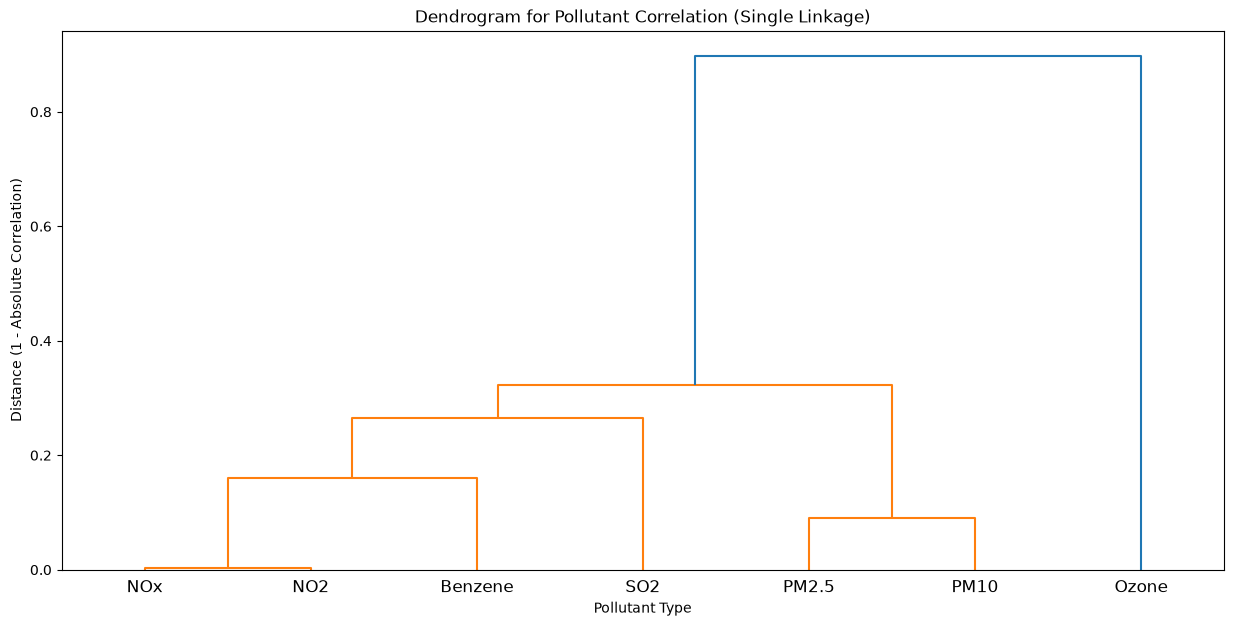

In [35]:
def plot_dendrogram(df, variables, method='single', title='Dendrogram', x_label='Variables', y_label='Distance'):
    """
    Plots a dendrogram for the given dataframe and variables.
    
    Parameters:
    - df: DataFrame containing the data
    - variables: List of variable names to include in the dendrogram
    - method: Linkage method for hierarchical clustering (default is 'single')
    - title: Title of the dendrogram plot
    """
    # Select only the specified columns
    df_selected = df[variables].dropna()  # Drop rows with NaN values
    
    # Calculate the correlation matrix
    correlation_matrix = df_selected.corr()
    
    # Convert correlation to distance: 1 - correlation
    distance_matrix = 1 - correlation_matrix.abs()
    
    # Convert to condensed distance matrix for linkage
    condensed_distance_matrix = squareform(distance_matrix)
    
    # Perform hierarchical clustering
    linked = linkage(condensed_distance_matrix, method=method)
    
    # Plot the dendrogram
    plt.figure(figsize=(15, 7))
    dendrogram(linked,
               orientation='top',
               labels=variables,
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()


plot_dendrogram(df_poll_pivot, pollutants, method='single', title='Dendrogram for Pollutant Correlation (Single Linkage)', x_label='Pollutant Type', y_label='Distance (1 - Absolute Correlation)')


There are 531250 rows with Ozone = 0 in the dataset out of a total of 1246981 rows.


<Axes: xlabel='Ozone', ylabel='Count'>

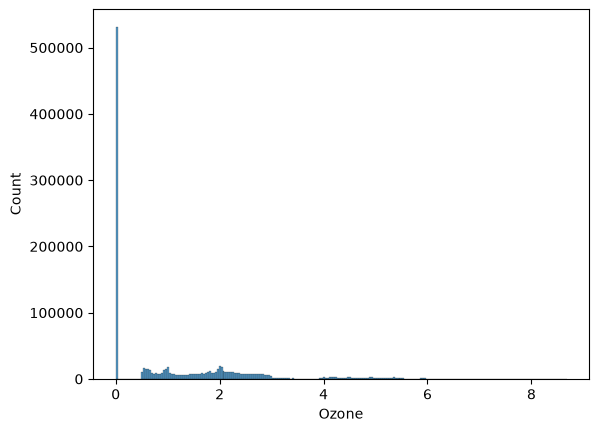

In [43]:
print(f"There are {np.sum(df_poll_pivot['Ozone']==0)} rows with Ozone = 0 in the dataset out of a total of {len(df_poll_pivot)} rows.")
sns.histplot(df_poll_pivot, x='Ozone')

The distribution of Ozone is highly skewed because it is a slightly different measure to the 

### Dendrogram
Dendrogram showing clusters of pollutants.

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.01,
    random_state=42
)
train_idx, sample_idx = next(
    splitter.split(df_poll_pivot, df_poll_pivot['year'])
)

df_sample = df_poll_pivot.iloc[sample_idx]
df_sample['year'] = df_sample['year'].astype(str)
print(len(df_sample))
print(df_poll_pivot['year'].value_counts(normalize=True))
print(df_sample['year'].value_counts(normalize=True))
years = sorted(df_sample['year'].unique())
print(years)

12470
year
2020    0.071466
2021    0.071466
2022    0.071466
2023    0.071466
2024    0.071466
2019    0.071462
2013    0.071460
2014    0.071460
2015    0.071460
2016    0.071460
2017    0.071460
2018    0.071460
2012    0.071459
2011    0.070989
Name: proportion, dtype: float64
year
2024    0.071532
2019    0.071451
2021    0.071451
2018    0.071451
2023    0.071451
2013    0.071451
2015    0.071451
2012    0.071451
2014    0.071451
2020    0.071451
2017    0.071451
2016    0.071451
2022    0.071451
2011    0.071051
Name: proportion, dtype: float64
['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


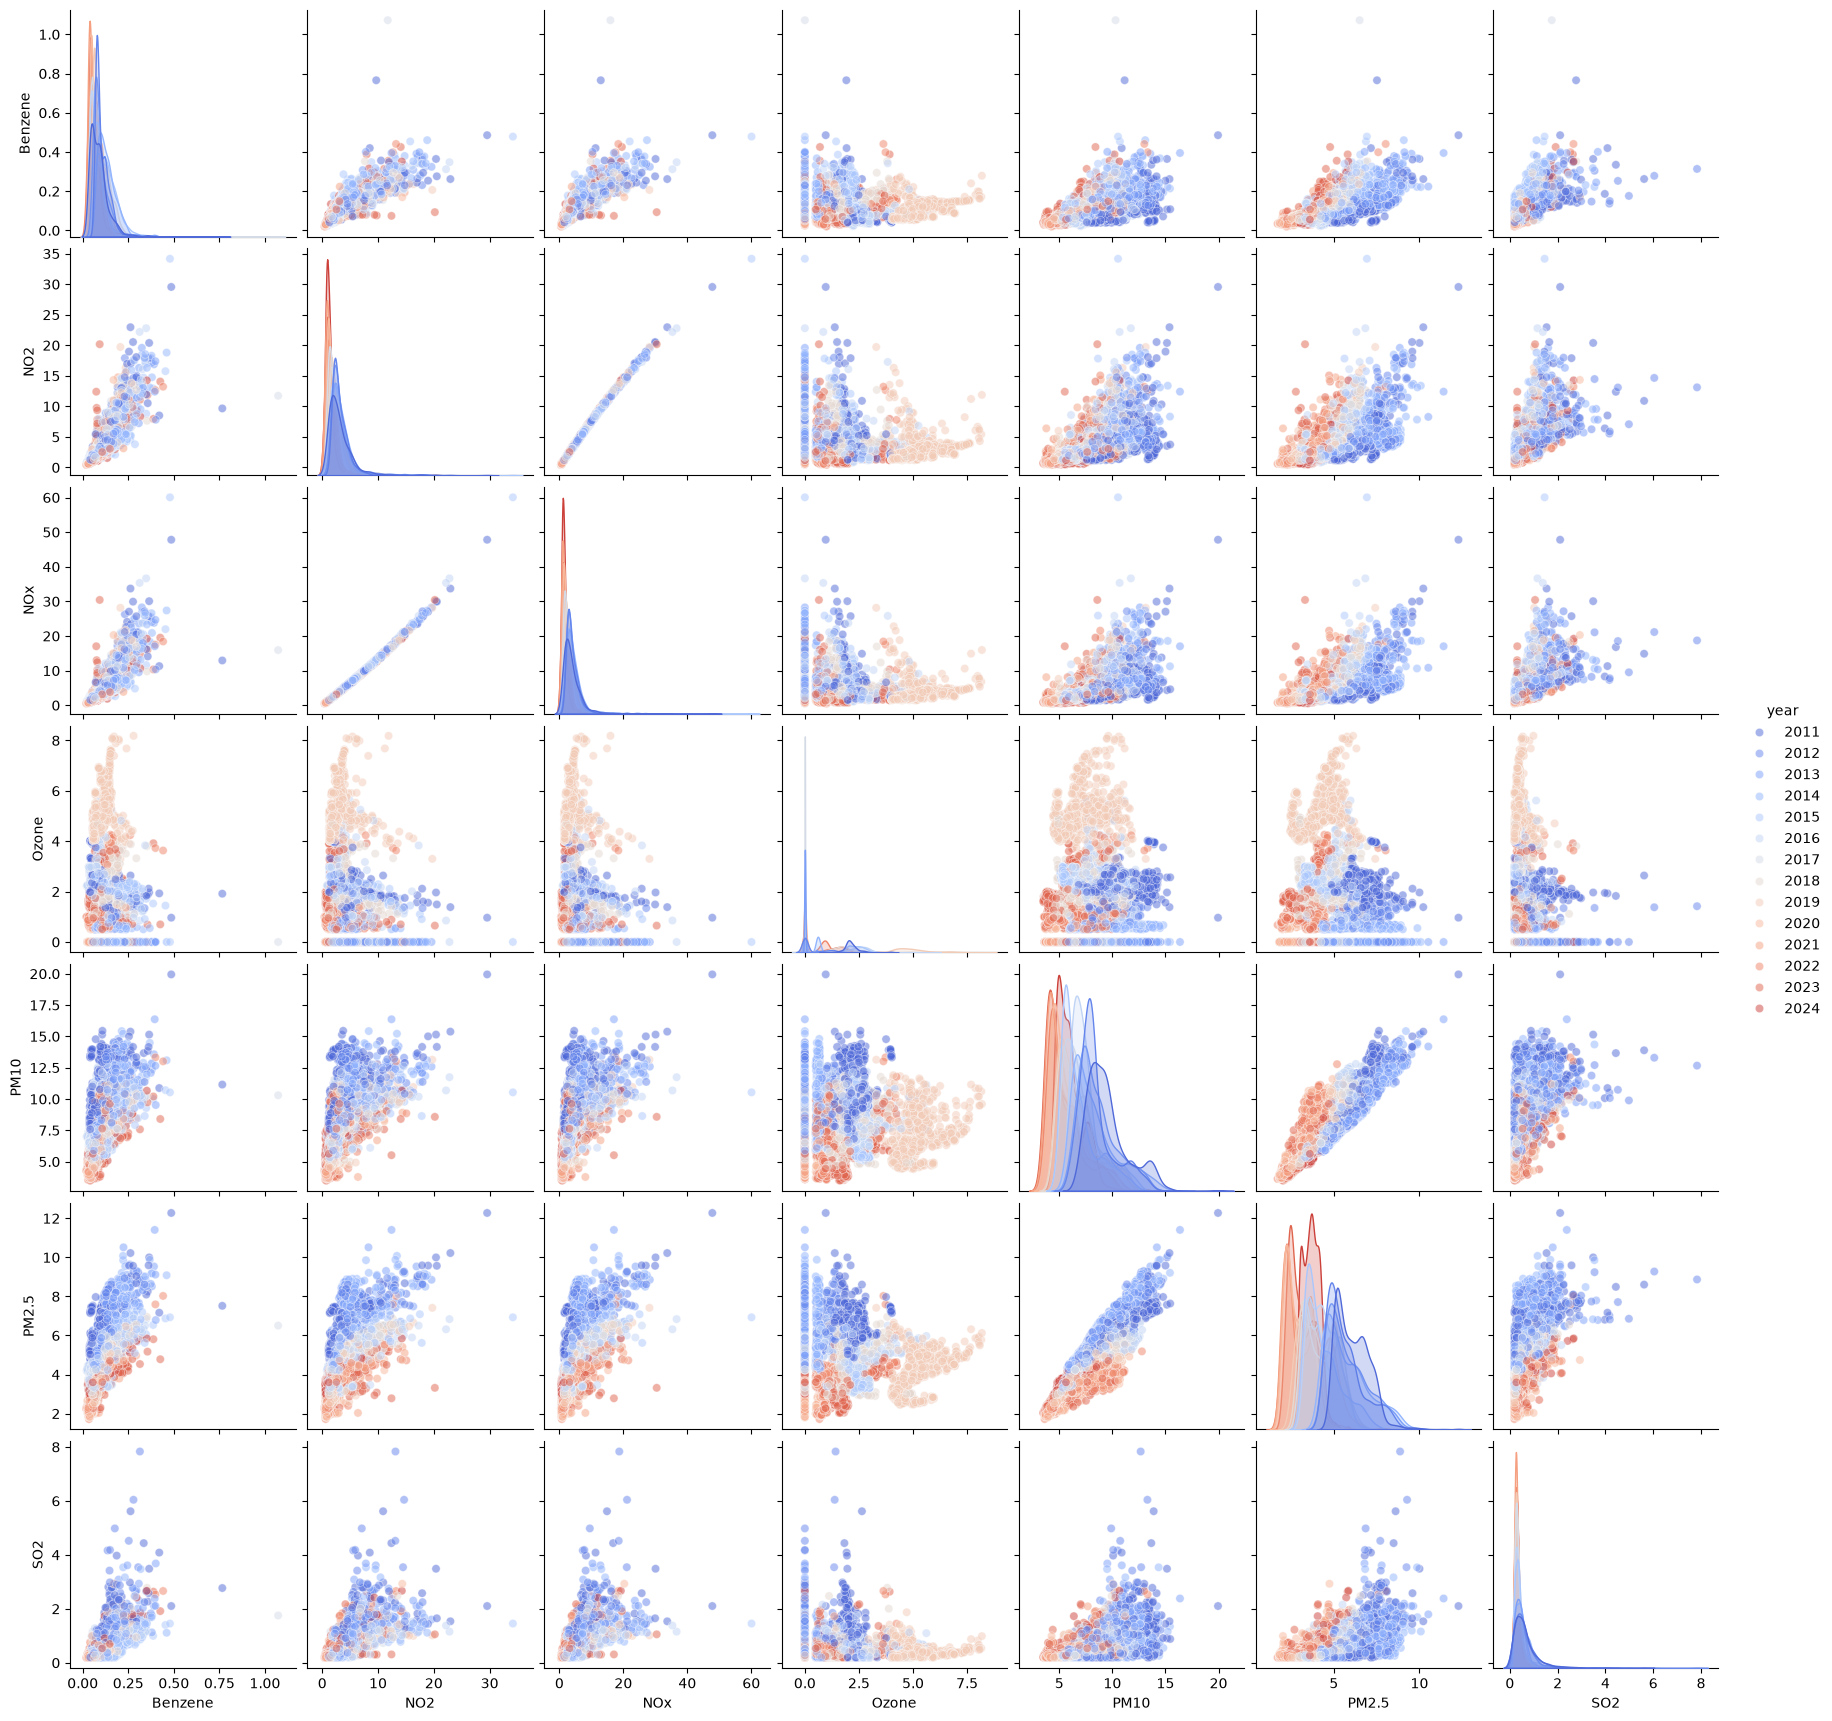

In [4]:
_ = sns.pairplot(df_sample, vars=pollutants, hue='year', hue_order=years, kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5}, palette='coolwarm')

## Climate - Correlation
This chart shows the correlation matrix for the climate variables

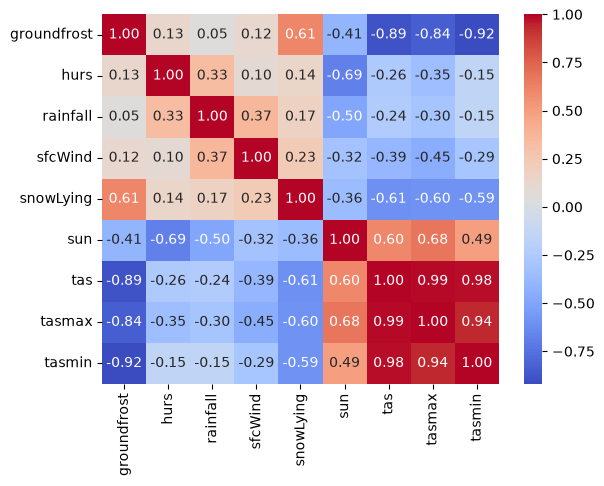

In [17]:
_ = sns.heatmap(df_clim_pivot[climate_measures].corr(), annot=True, cmap='coolwarm', fmt='.2f')


A pairwise scatter plot (after random sampling) shows the bivariate distributions of the climate variables. The charts show how well correlated all of the temperature variables are - tas, tasmin, and tasmax. So, our earlier decision to reduce to three under consideration is reinforced.
### Climate - Cluster Analysis
Here we use simple clustering to see which readings we can use to represent each different type of climate variable.

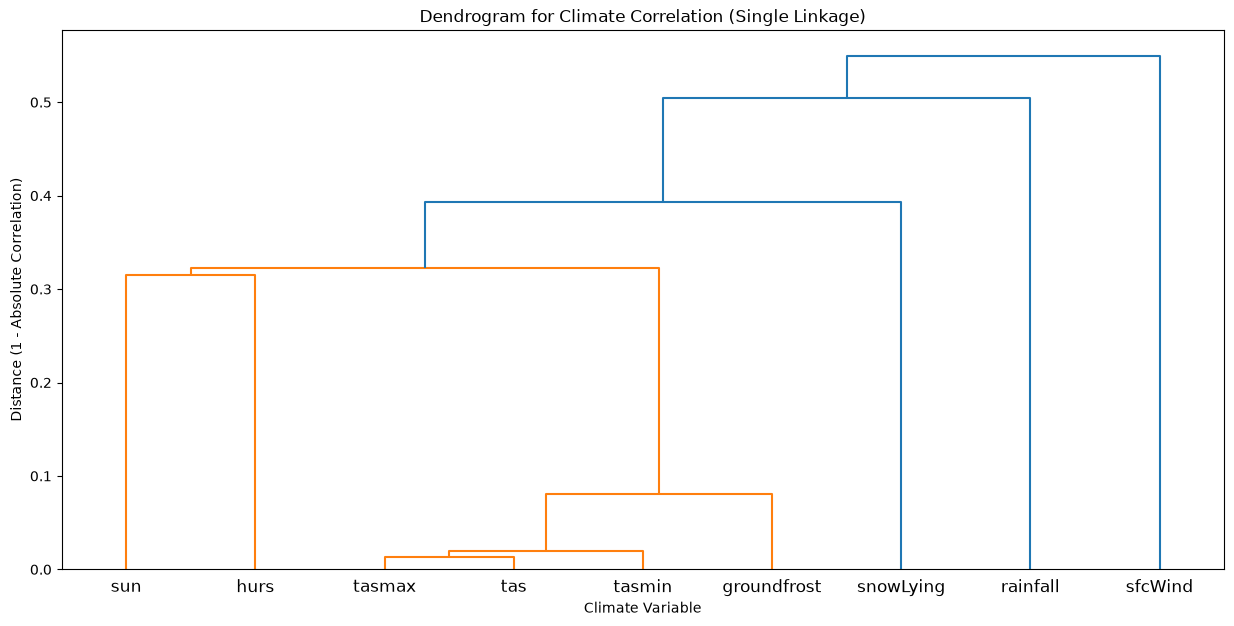

In [24]:
plot_dendrogram(df_clim_pivot, climate_measures, method='single', title='Dendrogram for Climate Correlation (Single Linkage)', x_label='Climate Variable', y_label='Distance (1 - Absolute Correlation)')


13916
year
2014    0.072103
2022    0.071379
2011    0.071377
2012    0.071377
2013    0.071377
2015    0.071377
2016    0.071377
2017    0.071377
2018    0.071377
2019    0.071377
2020    0.071377
2021    0.071377
2023    0.071377
2024    0.071377
Name: proportion, dtype: float64
year
2014    0.072147
2022    0.071429
2015    0.071429
2018    0.071429
2012    0.071357
2023    0.071357
2017    0.071357
2024    0.071357
2020    0.071357
2019    0.071357
2013    0.071357
2021    0.071357
2016    0.071357
2011    0.071357
Name: proportion, dtype: float64


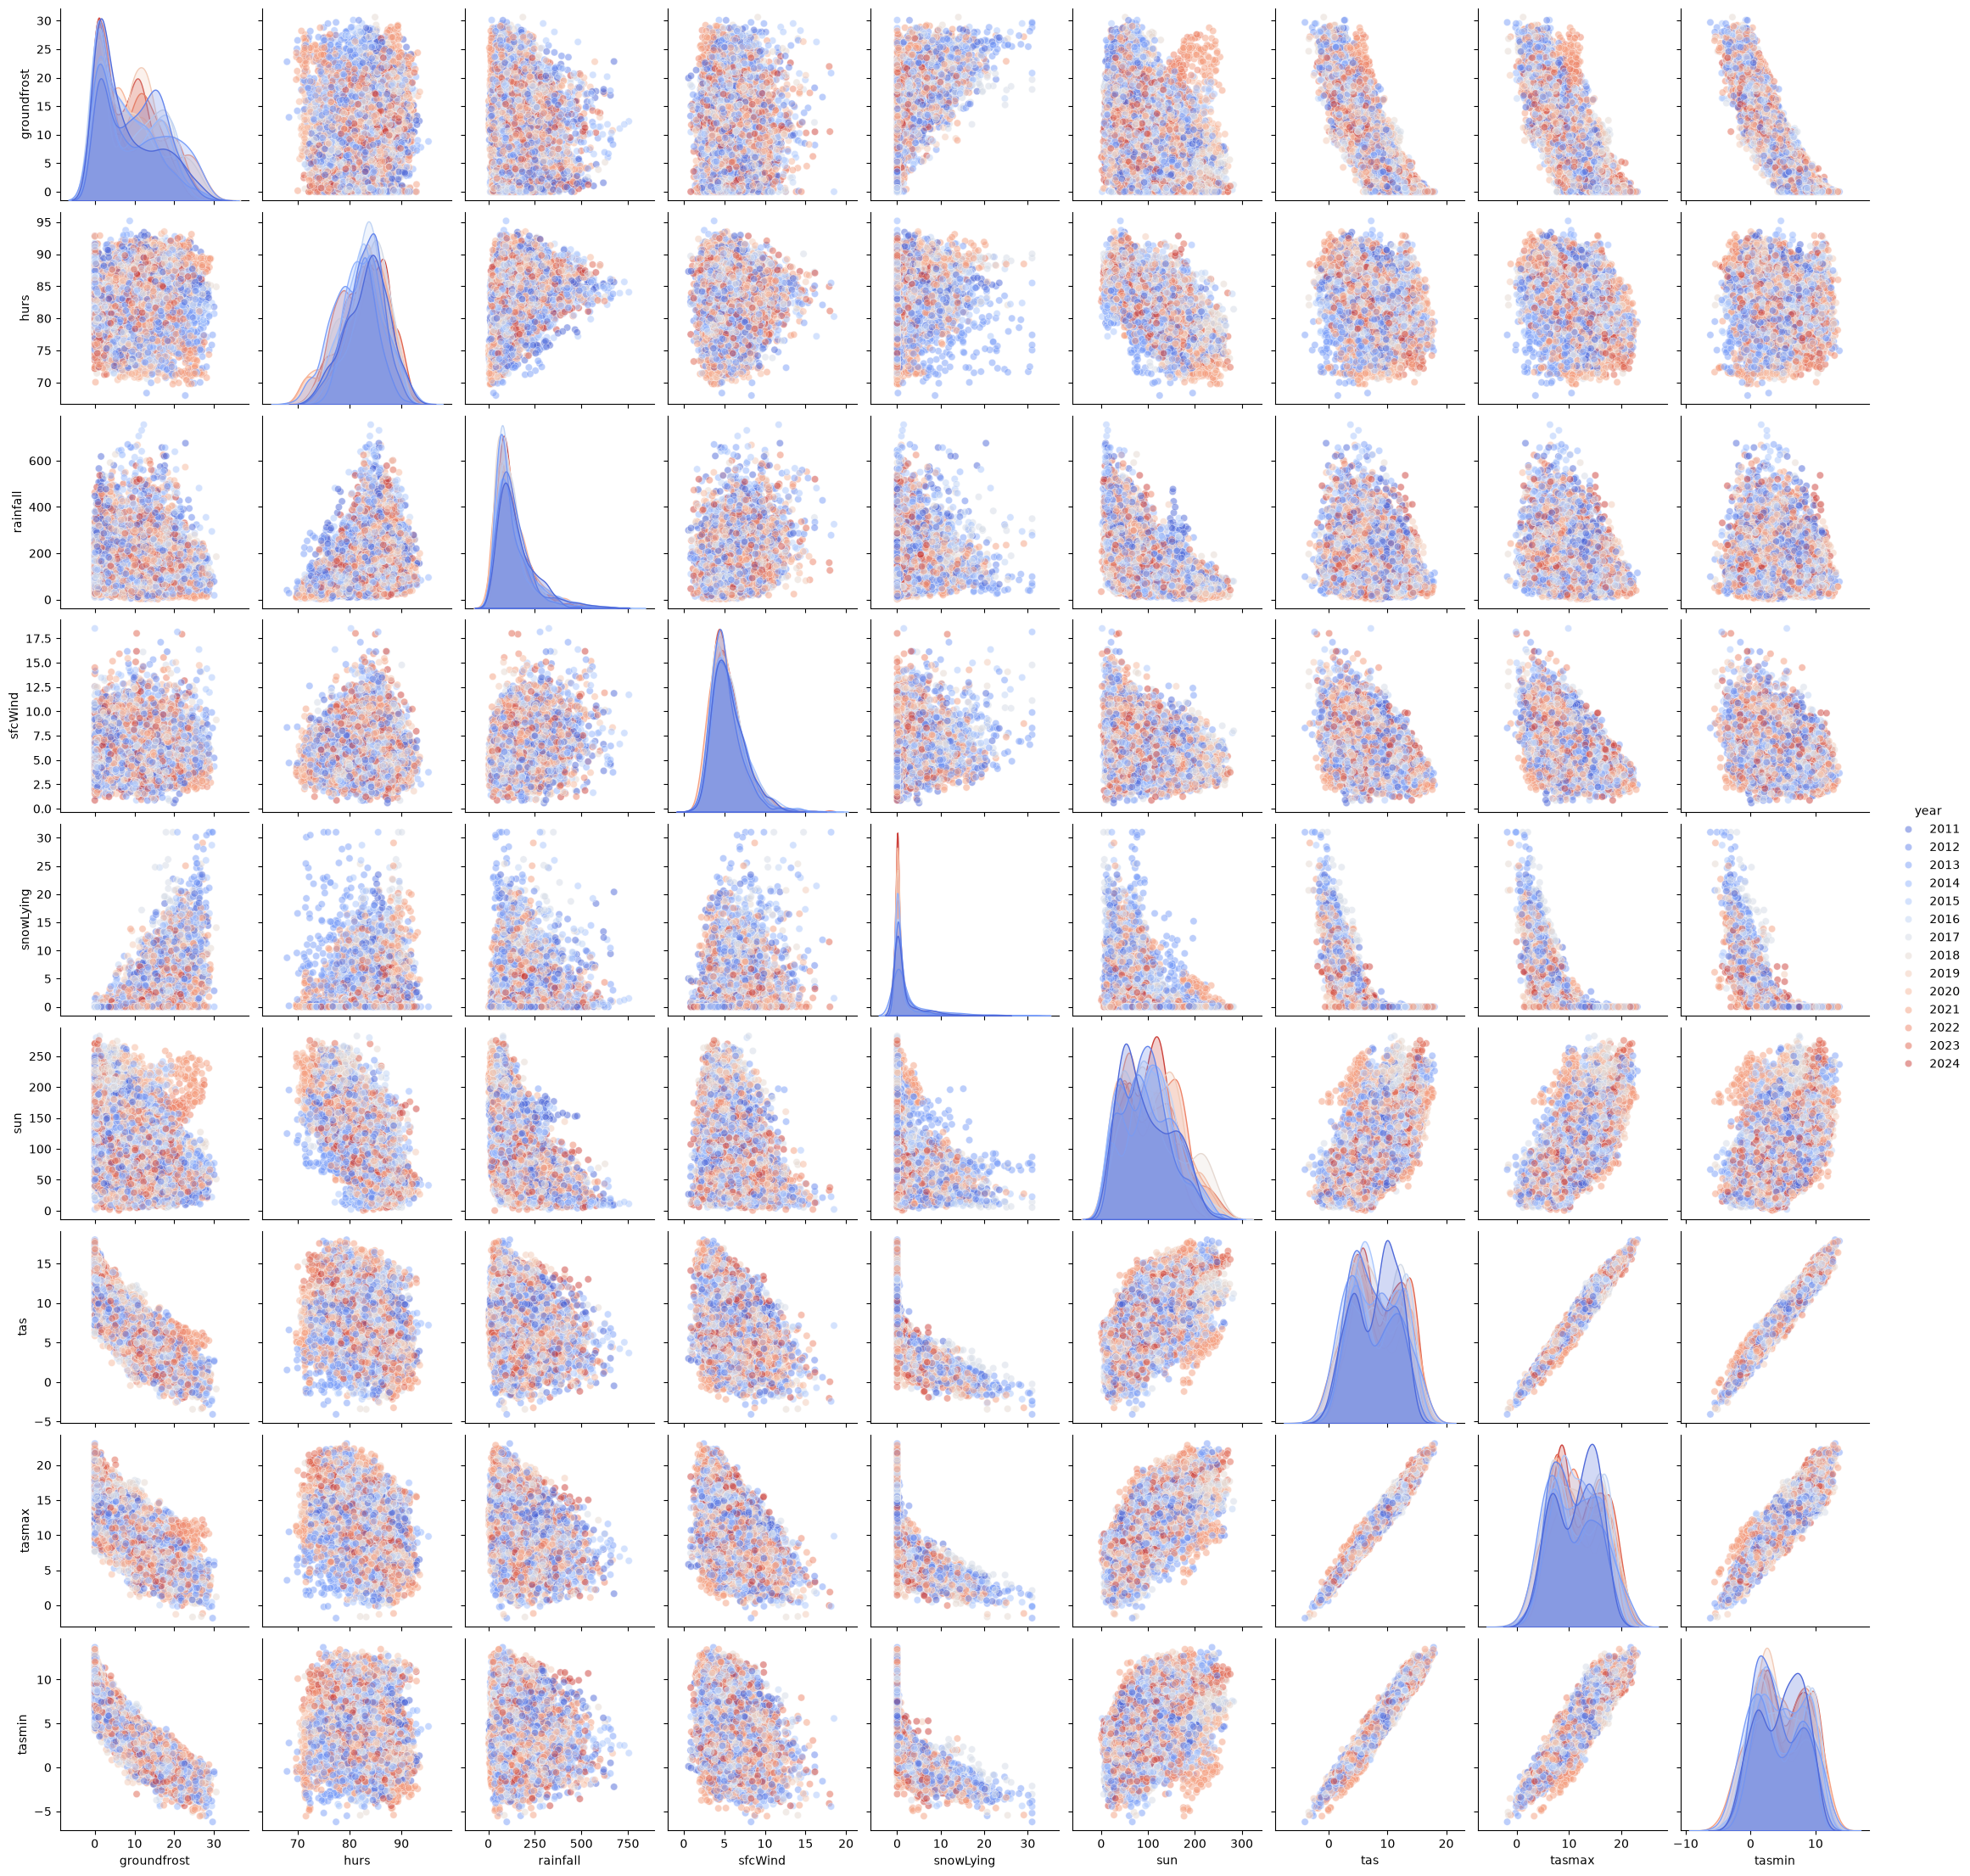

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
# stratified sampling to ensure representation of all years in the sample
# pairplot takes a long time to render with the full dataset, so we will take a small sample for visualization
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.001,
    random_state=42
)
train_idx, sample_idx = next(
    splitter.split(df_clim_pivot, df_clim_pivot['year'])
)

df_sample = df_clim_pivot.iloc[sample_idx]
df_sample['year'] = df_sample['year'].astype(str)
print(len(df_sample))
print(df_clim_pivot['year'].value_counts(normalize=True))
print(df_sample['year'].value_counts(normalize=True))
years = sorted(df_sample['year'].unique())

_ = sns.pairplot(df_sample, vars=climate_measures, hue='year', hue_order=years, kind='scatter', diag_kind='kde', plot_kws={'alpha':0.5}, palette='coolwarm' )

### Climate - PCA
This uses PCA to reduce the number of dimensions and see whether there are any patterns in the dataset. A couple of principal components do a good job of representing the variability in the dataset.

Proportion of variance explained:
  PC1: 0.662
  PC2: 0.145
  PC1 + PC2: 0.807


C:\Users\Tim\AppData\Local\Temp\ipykernel_27224\4126859609.py:119: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


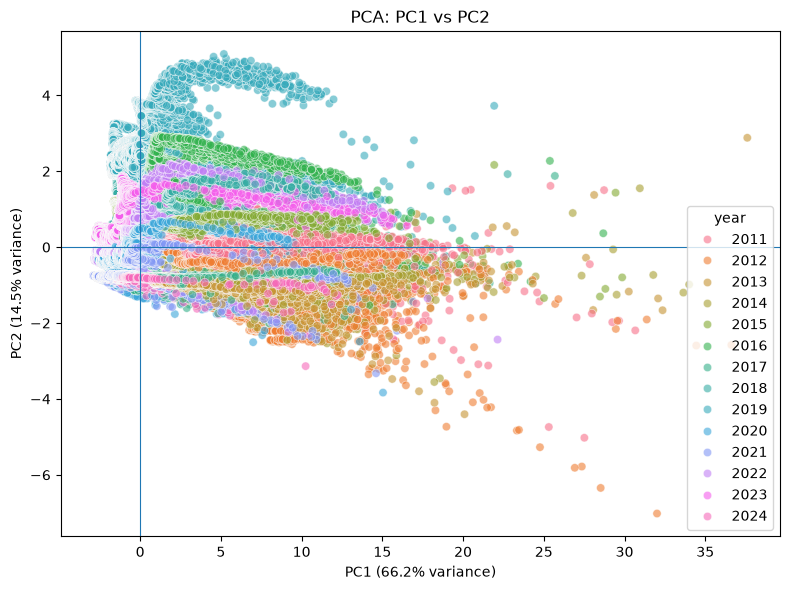

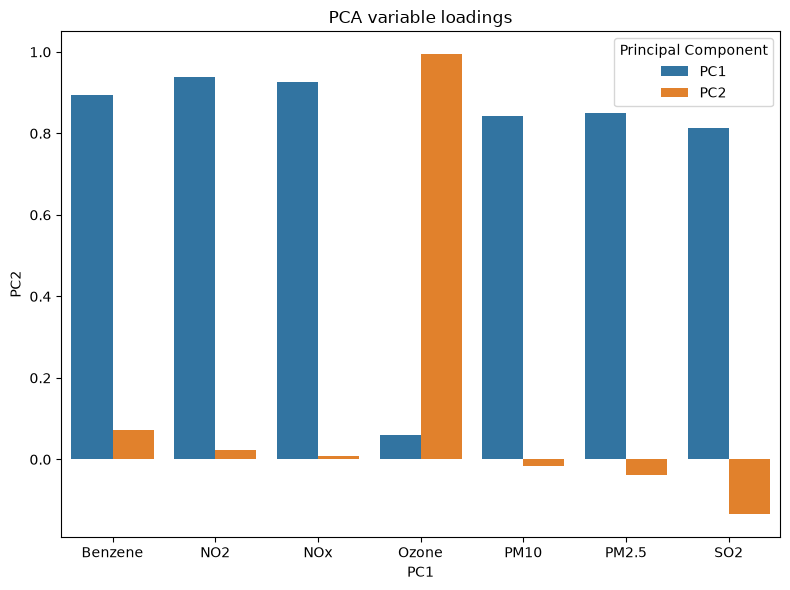

In [ ]:
def run_pca(df, variables, n_components=2, hue_col='year'):
    """
    Standardise variables, perform PCA, plot PC1 vs PC2,
    plot variable loadings, and print explained variance.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    variables : list
        Names of variables to include in the PCA.
    n_components : int, default=2
        Number of principal components to calculate.

    Returns
    -------
    pca : sklearn.decomposition.PCA
        Fitted PCA object.
    scores : pandas.DataFrame
        Principal component scores for each observation.
    loadings : pandas.DataFrame
        Loadings for each variable and principal component.
    """

    # --------------------------------------------------
    # 1. Extract variables and remove missing observations
    # --------------------------------------------------

    X = df[variables].dropna()

    # --------------------------------------------------
    # 2. Standardise variables
    # --------------------------------------------------

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --------------------------------------------------
    # 3. PCA
    # --------------------------------------------------

    pca = PCA(n_components=n_components)
    scores_array = pca.fit_transform(X_scaled)

    # Component scores
    scores = pd.DataFrame(
        scores_array,
        index=X.index,
        columns=[
            f'PC{i+1}'
            for i in range(n_components)
        ]
    )
    scores[hue_col] = df.loc[X.index, hue_col].astype(str) 

    # --------------------------------------------------
    # 4. Calculate loadings
    # --------------------------------------------------

    loadings_array = (
        pca.components_.T
        * np.sqrt(pca.explained_variance_)
    )

    loadings = pd.DataFrame(
        loadings_array,
        index=variables,
        columns=[
            f'PC{i+1}'
            for i in range(n_components)
        ]
    )

    # --------------------------------------------------
    # 5. Print explained variance
    # --------------------------------------------------

    print("Proportion of variance explained:")

    for i, variance in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {variance:.3f}")

    print(
        f"  PC1 + PC2: "
        f"{pca.explained_variance_ratio_[:2].sum():.3f}"
    )

    # --------------------------------------------------
    # 6. Scatterplot of PC1 vs PC2
    # --------------------------------------------------

    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=scores,
        x='PC1',
        y='PC2',
        hue=hue_col,
        alpha=0.6
    )

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
    )

    plt.title("PCA: PC1 vs PC2")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 7. Loading plot
    # --------------------------------------------------

    plt.figure(figsize=(8, 6))
    df_bar = loadings.reset_index().melt(id_vars='index', var_name='Principal Component', value_name='Loading')  
    sns.barplot(data=df_bar, x='index', y='Loading', hue='Principal Component')

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.title("PCA variable loadings")

    plt.tight_layout()
    plt.show()

    return pca, scores, loadings

get_princ_cp = run_pca(df_poll_pivot, pollutants, n_components=2)


The principal components show that the first component is loaded heavily on most of the pollutants except Ozone. I think we can separate out the pollution into high and low pollution using the first component as an indicator of general pollution level. If we were to use a second component, it could be Ozone. However, as we saw earlier, Ozone's correlation with other pollutants is likely to be a bad measure of independence because the distribution of Ozone is heavily skewed. Ozone is also a different type of measure to the other pollutants - days in excess of a threshold rather than concentration. 

Proportion of variance explained:
  PC1: 0.552
  PC2: 0.181
  PC1 + PC2: 0.733


C:\Users\Tim\AppData\Local\Temp\ipykernel_27224\4126859609.py:119: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


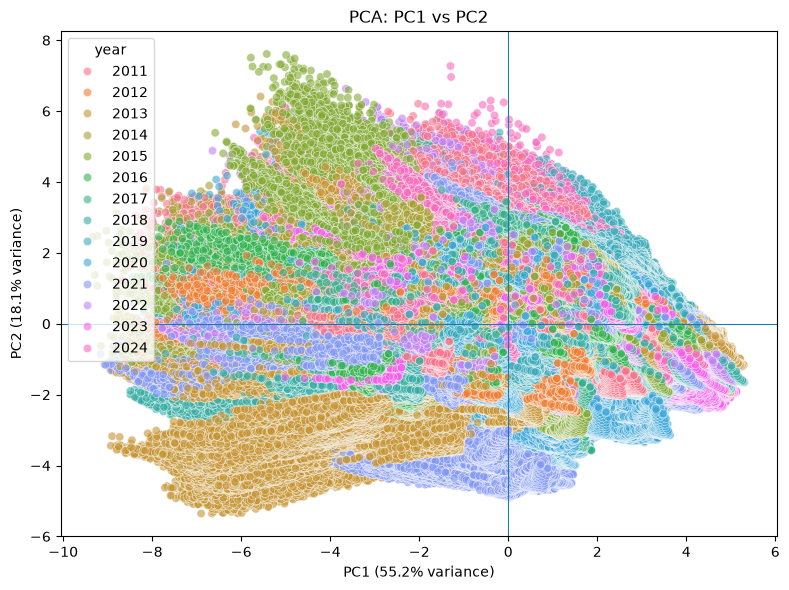

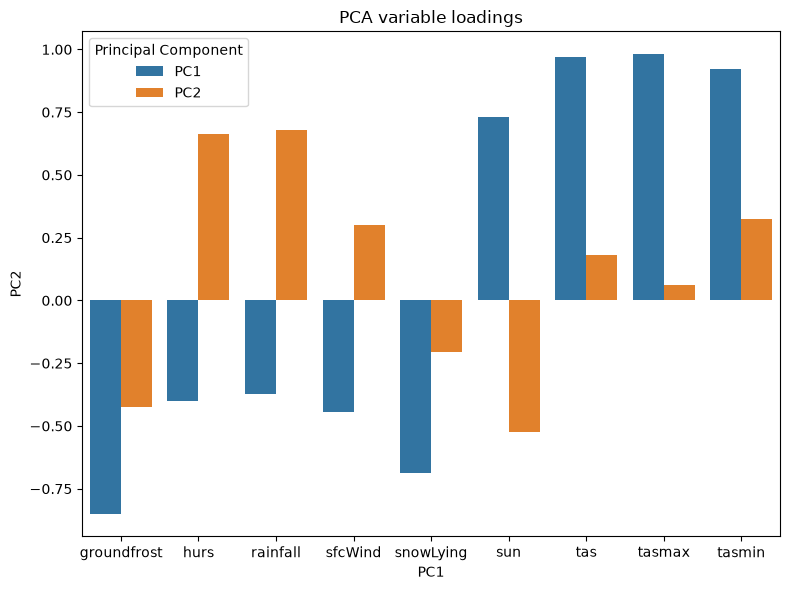

In [20]:
get_princ_cp = run_pca(df_clim_pivot, climate_measures, n_components=2)

So, the PCA for climate suggests that the loadngs for the first component consist largely of "warmth" measures - big positives on temperature and sun, and big negatives on groundfrost and snow. The second component is a "damp" index which has high loadings on "hurs" (relative humidity) and rainfall. This suggests that we can split climate points on these two axes to give us a classification scheme.


## Quantiles - Separate Regimes
The next steps show a routine for separating the data into quantiles based on standardised measures. This routine is then used to separate the
1. Climate Data into 6 groups - 3 separate Warmth regimes and 2 separated damp regimes
2. Pollution Data into 3 groups - high medium and low pollution based on average levels

In [ ]:
def create_quantile_indices(df, column_groups, names, num_quantiles):
    """
    Standardise groups of columns, average within each group,
    and divide each resulting index into n quantiles.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.

    column_groups : list of lists
        Groups of columns to combine.
        Example:
            [
                ["temperature", "sunshine"],
                ["humidity", "rainfall"]
            ]

    names : list of str
        Name for each resulting index.
        Example:
            ["Warm", "Damp"]

    n : int, default=3
        Number of quantiles.

    Returns
    -------
    pandas.DataFrame
        Original DataFrame plus index and quantile columns.
    """

    if len(column_groups) != len(names):
        raise ValueError(
            "column_groups and names must have the same length."
        )

    result = df.copy()

    for columns, name, n in zip(column_groups, names, num_quantiles):

        # Standardise columns
        scaler = StandardScaler()
        z = scaler.fit_transform(result[columns])

        # Average standardised values
        score = pd.DataFrame(
            z,
            index=result.index,
            columns=columns
        ).mean(axis=1)

        # Store continuous index
        result[name] = score

        # Create quantiles
        result[f"{name}_Q"] = pd.qcut(
            score,
            q=n,
            labels=[
                f"{name}_Q{i}"
                for i in range(1, n + 1)
            ]
        )

    return result

df_clim_pivot_with_indices = create_quantile_indices(df_clim_pivot, [["tas", "sun"], ["hurs", "rainfall"]], ["Warmth", "Dampness"], [3, 2])
df_clim_pivot_with_indices.groupby(['Warmth_Q', 'Dampness_Q']).size().unstack(fill_value=0)

In [1]:
df_poll_pivot_with_indices = create_quantile_indices(df_poll_pivot, [['Benzene', 'NO2', 'NOx', 'PM10', 'PM2.5', 'SO2']], ["Pollution"], [2])
df_poll_pivot_with_indices.groupby(['Pollution_Q']).size().unstack(fill_value=0)

NameError: name 'create_quantile_indices' is not defined